In [ ]:
!pip install -q -U datasets transformers matplotlib pandas

import re, itertools, textwrap
from collections import Counter
from typing import Dict
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

DATASET = "microsoft/OpenMementos"

ds_stream = load_dataset(DATASET, split="train", streaming=True)
first_row = next(iter(ds_stream))
print("Columns     :", list(first_row.keys()))
print("Domain      :", first_row["domain"], "| Source:", first_row["source"])
print("Problem head:", first_row["problem"][:160].replace("\n", " "), "...")

In [ ]:
BLOCK_RE   = re.compile(r"<\|block_start\|>(.*?)<\|block_end\|>",     re.DOTALL)
SUMMARY_RE = re.compile(r"<\|summary_start\|>(.*?)<\|summary_end\|>", re.DOTALL)
THINK_RE   = re.compile(r"<think>(.*?)</think>",                      re.DOTALL)

def parse_memento(response: str) -> Dict:
    blocks    = [m.strip() for m in BLOCK_RE.findall(response)]
    summaries = [m.strip() for m in SUMMARY_RE.findall(response)]
    think_m   = THINK_RE.search(response)
    final_ans = response.split("</think>")[-1].strip() if "</think>" in response else ""
    return {"blocks": blocks, "summaries": summaries,
            "reasoning": (think_m.group(1) if think_m else ""),
            "final_answer": final_ans}

parsed = parse_memento(first_row["response"])
print(f"\n→ {len(parsed['blocks'])} blocks, {len(parsed['summaries'])} mementos parsed")
print("First block   :", parsed["blocks"][0][:140].replace("\n", " "), "...")
print("First memento :", parsed["summaries"][0][:140].replace("\n", " "), "...")

N_SAMPLES = 500
rows = []
for i, ex in enumerate(itertools.islice(
        load_dataset(DATASET, split="train", streaming=True), N_SAMPLES)):
    p = parse_memento(ex["response"])
    if not p["blocks"] or len(p["blocks"]) != len(p["summaries"]):
        continue
    blk_c = sum(len(b) for b in p["blocks"])
    sum_c = sum(len(s) for s in p["summaries"])
    blk_w = sum(len(b.split()) for b in p["blocks"])
    sum_w = sum(len(s.split()) for s in p["summaries"])
    rows.append(dict(domain=ex["domain"], source=ex["source"],
                     n_blocks=len(p["blocks"]),
                     block_chars=blk_c, summ_chars=sum_c,
                     block_words=blk_w, summ_words=sum_w,
                     compress_char=sum_c / max(blk_c, 1),
                     compress_word=sum_w / max(blk_w, 1)))
    if (i + 1) % 100 == 0:
        print(f"  processed {i+1}/{N_SAMPLES}")

df = pd.DataFrame(rows)
print(f"\nAnalyzed {len(df)} rows. Domain counts:")
print(df["domain"].value_counts().to_string())

per_dom = df.groupby("domain").agg(
    n=("domain", "count"),
    median_blocks=("n_blocks", "median"),
    median_block_words=("block_words", "median"),
    median_summ_words=("summ_words", "median"),
    median_char_ratio=("compress_char", "median"),
    median_word_ratio=("compress_word", "median"),
).round(3)
print("\nPer-domain medians (ratio = mementos / blocks):")
print(per_dom.to_string())

In [ ]:
def compress_trace(response: str, keep_last_k: int = 1) -> str:
    blocks, summaries = BLOCK_RE.findall(response), SUMMARY_RE.findall(response)
    if not blocks or len(blocks) != len(summaries):
        return response
    out, n = ["<think>"], len(blocks)
    for i, (b, s) in enumerate(zip(blocks, summaries)):
        if i >= n - keep_last_k:
            out.append(f"<|block_start|>{b}<|block_end|>")
            out.append(f"<|summary_start|>{s}<|summary_end|>")
        else:
            out.append(f"<|summary_start|>{s}<|summary_end|>")
    out.append("</think>")
    out.append(response.split("</think>")[-1])
    return "\n".join(out)

orig, comp = first_row["response"], compress_trace(first_row["response"], 1)
print(f"\nOriginal   : {len(orig):>8,} chars")
print(f"Compressed : {len(comp):>8,} chars ({len(comp)/len(orig)*100:.1f}% of original)")

from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("gpt2")
MEM_TOKENS = ["<|block_start|>", "<|block_end|>",
              "<|summary_start|>", "<|summary_end|>",
              "<think>", "</think>"]
tok.add_special_tokens({"additional_special_tokens": MEM_TOKENS})

def tlen(s): return len(tok(s, add_special_tokens=False).input_ids)

blk_tok = sum(tlen(b) for b in parsed["blocks"])
sum_tok = sum(tlen(s) for s in parsed["summaries"])
print(f"\nTrace-level token compression for this example:")
print(f"  block tokens    = {blk_tok}")
print(f"  memento tokens  = {sum_tok}")
print(f"  compression     = {blk_tok / max(sum_tok,1):.2f}×  (paper reports ~6×)")

def to_chat(ex):
    return {"messages": [
        {"role": "user",      "content": ex["problem"]},
        {"role": "assistant", "content": ex["response"]},
    ]}
chat_stream = load_dataset(DATASET, split="train", streaming=True).map(to_chat)
chat_ex = next(iter(chat_stream))
print("\nSFT chat example (truncated):")
for m in chat_ex["messages"]:
    print(f"  [{m['role']:9s}] {m['content'][:130].replace(chr(10),' ')}...")

In [ ]:
def compress_trace(response: str, keep_last_k: int = 1) -> str:
    blocks, summaries = BLOCK_RE.findall(response), SUMMARY_RE.findall(response)
    if not blocks or len(blocks) != len(summaries):
        return response
    out, n = ["<think>"], len(blocks)
    for i, (b, s) in enumerate(zip(blocks, summaries)):
        if i >= n - keep_last_k:
            out.append(f"<|block_start|>{b}<|block_end|>")
            out.append(f"<|summary_start|>{s}<|summary_end|>")
        else:
            out.append(f"<|summary_start|>{s}<|summary_end|>")
    out.append("</think>")
    out.append(response.split("</think>")[-1])
    return "\n".join(out)

orig, comp = first_row["response"], compress_trace(first_row["response"], 1)
print(f"\nOriginal   : {len(orig):>8,} chars")
print(f"Compressed : {len(comp):>8,} chars ({len(comp)/len(orig)*100:.1f}% of original)")

from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("gpt2")
MEM_TOKENS = ["<|block_start|>", "<|block_end|>",
              "<|summary_start|>", "<|summary_end|>",
              "<think>", "</think>"]
tok.add_special_tokens({"additional_special_tokens": MEM_TOKENS})

def tlen(s): return len(tok(s, add_special_tokens=False).input_ids)

blk_tok = sum(tlen(b) for b in parsed["blocks"])
sum_tok = sum(tlen(s) for s in parsed["summaries"])
print(f"\nTrace-level token compression for this example:")
print(f"  block tokens    = {blk_tok}")
print(f"  memento tokens  = {sum_tok}")
print(f"  compression     = {blk_tok / max(sum_tok,1):.2f}×  (paper reports ~6×)")

def to_chat(ex):
    return {"messages": [
        {"role": "user",      "content": ex["problem"]},
        {"role": "assistant", "content": ex["response"]},
    ]}
chat_stream = load_dataset(DATASET, split="train", streaming=True).map(to_chat)
chat_ex = next(iter(chat_stream))
print("\nSFT chat example (truncated):")
for m in chat_ex["messages"]:
    print(f"  [{m['role']:9s}] {m['content'][:130].replace(chr(10),' ')}...")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 945.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incomp

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Columns     : ['problem', 'response', 'domain', 'source', 'difficulty']
Domain      : code | Source: stackexchange_codegolf
Problem head: The problem over here introduces an new type of strings: if you split the string into equal halfs and swap the pairs, it produces the same output as sorting the ...

→ 7 blocks, 7 mementos parsed
First block   : Okay, so I need to figure out how to determine if a given string is a half-sort. Hmm, let's start by understanding the problem again. The ha ...
First memento : Clarifies definition of half-sort: split string into two halves (first half longer if length odd), swap halves; if swapped string equals the ...


Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

  processed 100/500
  processed 200/500
  processed 300/500
  processed 400/500
  processed 500/500

Analyzed 500 rows. Domain counts:
domain
code    500

Per-domain medians (ratio = mementos / blocks):
          n  median_blocks  median_block_words  median_summ_words  median_char_ratio  median_word_ratio
domain                                                                                                 
code    500            9.0              7405.0              902.0              0.158              0.126


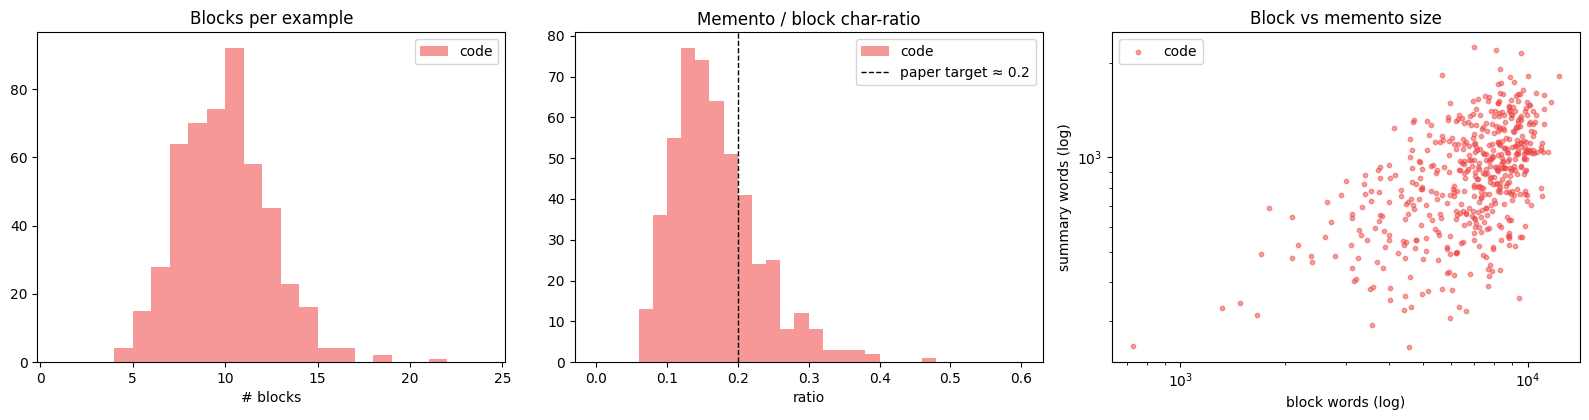

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]


[full subset] extra columns: ['sentences', 'blocks', 'block_summaries']
# sentences=60  # blocks=7  # block_summaries=7
Block-0 sentence range = [0, 4]  (length 5 sentences)
  • Okay, so I need to figure out how to determine if a given string is a half-sort. Hmm, let's start by understanding the p
  • Let me rephrase the example given. Take the string "node".

Original   :   17,027 chars
Compressed :    6,811 chars (40.0% of original)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]


Trace-level token compression for this example:
  block tokens    = 3386
  memento tokens  = 994
  compression     = 3.41×  (paper reports ~6×)


Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]


SFT chat example (truncated):
  [user     ] The problem over here introduces an new type of strings: if you split the string into equal halfs and swap the pairs, it produces ...
  [assistant] <think><|block_start|>Okay, so I need to figure out how to determine if a given string is a half-sort. Hmm, let's start by underst...
7 blocks · 7 mementos

▶ BLOCK 1  (809 chars)
  Okay, so I need to figure out how to determine if a given string is a half-sort. Hmm, let's start by understanding the problem again. The half-sort is when if you split the string into two equal halves (with the [...]
◀ MEMENTO 1  (319 chars · 39.4% of block)
  Clarifies definition of half-sort: split string into two halves (first half longer if length odd), swap halves; if swapped string equals the sorted string (by ASCII/codepoints), input is considered half-sort. [...]

▶ BLOCK 2  (2,608 chars)
  The task is to write a function that checks if a given string satisfies this condition. So the steps I need to do are: 1

In [ ]:
def render_trace(response: str, width: int = 220) -> None:
    p = parse_memento(response)
    print("=" * 72)
    print(f"{len(p['blocks'])} blocks · {len(p['summaries'])} mementos")
    print("=" * 72)
    for i, (b, s) in enumerate(zip(p["blocks"], p["summaries"]), 1):
        ratio = len(s) / max(len(b), 1) * 100
        print(f"\n▶ BLOCK {i}  ({len(b):,} chars)")
        print(textwrap.indent(textwrap.shorten(b.replace("\n", " "), width=width), "  "))
        print(f"◀ MEMENTO {i}  ({len(s):,} chars · {ratio:.1f}% of block)")
        print(textwrap.indent(textwrap.shorten(s.replace("\n", " "), width=width), "  "))
    if p["final_answer"]:
        print("\n★ FINAL ANSWER")
        print(textwrap.indent(textwrap.shorten(p["final_answer"].replace("\n"," "),
                                               width=width*2), "  "))

render_trace(first_row["response"])